In [ ]:
import os
import torch
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
from scipy.stats import skew
import matplotlib.pyplot as plt

from sklearn.utils import resample

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.inspection import permutation_importance
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score,precision_score, roc_auc_score
from sklearn.decomposition import PCA
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
root_dir = r'smaller_dataset.csv'
df = pd.read_csv(root_dir)
df["Weight"] = df["Total Fwd Packet"] * df["Total Bwd packets"]

In [ ]:
categorical_columns = ["Src IP", 'Dst IP', "Src Port", "Dst Port", "Protocol"] 

for col in categorical_columns:
    df[col] = df[col].astype('category')

for col in ['Src IP', 'Dst IP', 'Src Port', 'Dst Port']:
    df[col + '_freq'] = df[col].map(df[col].value_counts())

df = pd.get_dummies(df, columns=['Protocol'], prefix='Proto')

In [4]:
df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Timestamp',
       'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance

In [5]:
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Attack_Type,Weight,Src IP_freq,Dst IP_freq,Src Port_freq,Dst Port_freq,Proto_0,Proto_6,Proto_17
0,192.168.137.144-192.168.137.240-49153-13217-6,192.168.137.144,49153,192.168.137.240,13217,05/08/2022 10:53:38 AM,18188538,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.274898,4547134.5,2.655540e+06,6473349.0,672643.0,0.0,0.0,0.0,0.0,0.0,13184858.0,4.394953e+06,3.230926e+06,6473349.0,672643.0,0,0,0,0,24,80,0.054980,0.219919,0.0,0.0,0.000000,0.000000,0.000000,0,4,1,0,1,0,0,0,4.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,5.838632e+06,755017.935929,6473349.0,5003680.0,NeedManualLabel,DoS_DoS SYN Flood,4,1361,1363,1417,1,False,True,False
1,192.168.137.65-192.168.137.171-7661-6668-6,192.168.137.65,7661,192.168.137.171,6668,26/10/2022 11:53:56 AM,99736150,2,0,2920.0,0.0,1460.0,1460.0,1460.0,0.0,0.0,0.0,0.0,0.0,29.277248,0.020053,99736150.0,0.000000e+00,99736150.0,99736150.0,99736150.0,99736150.0,0.0,99736150.0,99736150.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,0,0,40,0,0.020053,0.000000,1460.0,1460.0,1460.000000,0.000000,0.000000,0,0,0,0,2,0,0,0,0.0,2190.0,1460.0,0.0,0,0,0,0,0,0,2,2920,0,0,512,0,1,20,0.0,0.0,0.0,0.0,9.973615e+07,0.000000,99736150.0,99736150.0,NeedManualLabel,DDoS_DDoS ACK Fragmentation,0,658,116,1,9306,False,True,False
2,192.168.137.12-192.168.137.235-15376-8008-6,192.168.137.12,15376,192.168.137.235,8008,26/10/2022 03:46:03 PM,88834040,2,0,2920.0,0.0,1460.0,1460.0,1460.0,0.0,0.0,0.0,0.0,0.0,32.870283,0.022514,88834040.0,0.000000e+00,88834040.0,88834040.0,88834040.0,88834040.0,0.0,88834040.0,88834040.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,0,0,40,0,0.022514,0.000000,1460.0,1460.0,1460.000000,0.000000,0.000000,0,0,0,0,2,0,0,0,0.0,2190.0,1460.0,0.0,0,0,0,0,0,0,2,2920,0,0,512,0,1,20,0.0,0.0,0.0,0.0,8.883404e+07,0.000000,88834040.0,88834040.0,NeedManualLabel,DDoS_DDoS ACK Fragmentation,0,283,777,2,960,False,True,False
3,192.168.137.12-192.168.137.206-21499-55442-6,192.168.137.12,21499,192.168.137.206,55442,26/10/2022 04:50:41 PM,17797062,1,1,1460.0,0.0,1460.0,1460.0,1460.0,0.0,0.0,0.0,0.0,0.0,82.036012,0.112378,17797062.0,0.000000e+00,17797062.0,17797062.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,0,0,20,20,0.056189,0.056189,0.0,1460.0,973.333333,842.931393,710533.333333,0,0,1,0,1,0,0,0,1.0,1460.0,1460.0,0.0,0,0,0,0,0,0,1,1460,1,0,512,0,0,20,0.0,0.0,0.0,0.0,1.779706e+07,0.000000,17797062.0,17797062.0,NeedManualLabel,DDoS_DDoS ACK Fragmentation,1,283,131,1,702,False,True,False
4,192.168.137.225-192.168.137.132-38616-8080-6,192.168.137.225,38616,192.168.137.132,8080,14/09/2022 11:10:19 AM,294063,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,6.801264,294063.0,0.000000e+00,294063.0,294063.0,0

In [6]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'],  format='%d/%m/%Y %I:%M:%S %p')

In [ ]:
attacks_to_remove = [
    "spoofing_ARP Spoofing",
    "spoofing_DNS Spoofing",
    "sqlinjection",
    "XSS",
    "Uploading_Attack"
]

df = df[~df["Attack_Type"].isin(attacks_to_remove)]

In [8]:
columns_to_drop = ["Flow IAT Std",
                   "Bwd Segment Size Avg",
                   "Subflow Fwd Packets",
    'Flow Duration',
    'Subflow Bwd Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Flow Packets/s',
    'Flow IAT Min',
    'Flow IAT Max',
    'Bwd IAT Max',
    'Bwd IAT Min',
    'Fwd Header Length',
    'ACK Flag Count',
    'Packet Length Std',
    "Fwd IAT Max",
    "Idle Max",
    "Idle Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    'Average Packet Size',
    'Fwd Segment Size Avg',
    'Fwd IAT Max',
    'Bwd Header Length',
    'Packet Length Mean',
    'CWR Flag Count',
    'Average Packet Size',
    "Flow IAT Mean",
    "Active Max",
    "Bwd Bytes/Bulk Avg",
    'Fwd IAT Mean',
    'Active Mean',
    'Active Std',
    "Fwd Act Data Pkts"
]

df = df.drop(columns=columns_to_drop)
df = df.drop(columns="Label")

def create_anomaly_label(row):
    if row['Attack_Type'] == 'Benign&Bruteforce_benign':
        return 'Normal'
    else:
        return 'Attack'

df['Anomaly_Label'] = df.apply(create_anomaly_label, axis=1)

null_columns = df.isnull().sum()
null_columns = null_columns[null_columns > 0]


inf_columns = df.columns[(df == np.inf).any() | (df == -np.inf).any()]

df = df.dropna()

df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]

df.replace([np.inf, -np.inf], np.nan, inplace=True)




In [ ]:
X = df.select_dtypes(include=['number', 'bool'])
X_datetime = df.select_dtypes(include=['datetime64'])
y = df['Anomaly_Label']  
y = (y == "Attack").astype(int) 


np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


for col in X_datetime.columns:
    X_datetime[col] = pd.to_datetime(X_datetime[col]).astype('int64') // 10**9


scaler_numerical = StandardScaler()
X_scaled_num = scaler_numerical.fit_transform(X)


scaler_datetime = StandardScaler()
X_scaled_datetime = scaler_datetime.fit_transform(X_datetime)


X_scaled= np.concatenate([X_scaled_num, X_scaled_datetime], axis=1)

pca = PCA(n_components=0.95)  

X_scaled = pca.fit_transform(X_scaled)


X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)


X_train = X_train_full[y_train_full == 0]



X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.bool)

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=64, shuffle=True)


Using device: cuda


In [ ]:
import torch
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, activation=nn.ReLU(), dropout_rate=0.0,
                 sequence_length=1, num_layers=1, bidirectional=False):
        super(LSTMAutoencoder, self).__init__()

        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.bottleneck_dim = hidden_dims[-1]
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.directions = 2 if bidirectional else 1
        self.activation = activation

        
        self.encoder_layers = nn.ModuleList()
        prev_dim = input_dim
        for h_dim in hidden_dims:
            self.encoder_layers.append(nn.LSTM(
                input_size=prev_dim,
                hidden_size=h_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ))
            prev_dim = h_dim * self.directions

        
        self.decoder_layers = nn.ModuleList()
        reversed_dims = list(reversed(hidden_dims))
        prev_dim = reversed_dims[0] * self.directions

       
        for i in range(len(reversed_dims) - 1):
            next_dim = reversed_dims[i+1]
            self.decoder_layers.append(nn.LSTM(
                input_size=prev_dim,
                hidden_size=next_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ))
            prev_dim = next_dim * self.directions

        
        self.output_layer = nn.Linear(hidden_dims[0] * self.directions, input_dim)

        
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

    def forward(self, x):
        
        original_shape = x.shape
        if len(x.shape) == 2:
            x = x.unsqueeze(1)  

        batch_size = x.size(0)
        seq_len = x.size(1)

        
        current_input = x
        for i, encoder in enumerate(self.encoder_layers):
            outputs, (hidden, cell) = encoder(current_input)
            current_input = outputs

            if self.activation is not None:
                current_input = self.activation(current_input)

            if self.dropout is not None and i < len(self.encoder_layers) - 1:
                current_input = self.dropout(current_input)

       
        encoded = outputs[:, -1, :]

        decoder_input = encoded.unsqueeze(1).repeat(1, seq_len, 1)

        current_input = decoder_input
        for i, decoder in enumerate(self.decoder_layers):
            outputs, _ = decoder(current_input)
            current_input = outputs

            if self.activation is not None and i < len(self.decoder_layers) - 1:
                current_input = self.activation(current_input)

            if self.dropout is not None and i < len(self.decoder_layers) - 1:
                current_input = self.dropout(current_input)

        reconstructed = self.output_layer(current_input)

        if len(original_shape) == 2:
            reconstructed = reconstructed.squeeze(1)

        return reconstructed, encoded

In [ ]:
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


input_dim = X_train.shape[1]
hidden_dims = [24,12]  
sequence_length = 5  

model = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dims=hidden_dims,
    sequence_length=sequence_length,
    num_layers=1,
    bidirectional=True,
    dropout_rate=0.1
).to(device)



batch_size = 32

x = torch.randn(batch_size, sequence_length, input_dim)
x = x.to(device)


Using device: cuda


Epoch 1/30, Train Loss: 0.4128, Test Loss: 0.3372
Epoch 2/30, Train Loss: 0.2350, Test Loss: 0.2881
Epoch 3/30, Train Loss: 0.2135, Test Loss: 0.2706
Epoch 4/30, Train Loss: 0.2010, Test Loss: 0.2593
Epoch 5/30, Train Loss: 0.1909, Test Loss: 0.2539
Epoch 6/30, Train Loss: 0.1826, Test Loss: 0.2435
Epoch 7/30, Train Loss: 0.1766, Test Loss: 0.2404
Epoch 8/30, Train Loss: 0.1709, Test Loss: 0.2374
Epoch 9/30, Train Loss: 0.1651, Test Loss: 0.2311
Epoch 10/30, Train Loss: 0.1578, Test Loss: 0.2252
Epoch 11/30, Train Loss: 0.1551, Test Loss: 0.2207
Epoch 12/30, Train Loss: 0.1497, Test Loss: 0.2171
Epoch 13/30, Train Loss: 0.1470, Test Loss: 0.2159
Epoch 14/30, Train Loss: 0.1405, Test Loss: 0.2184
Epoch 15/30, Train Loss: 0.1336, Test Loss: 0.2082
Epoch 16/30, Train Loss: 0.1323, Test Loss: 0.2061
Epoch 17/30, Train Loss: 0.1265, Test Loss: 0.2035
Epoch 18/30, Train Loss: 0.1227, Test Loss: 0.2092
Epoch 19/30, Train Loss: 0.1346, Test Loss: 0.2021
Epoch 20/30, Train Loss: 0.1259, Test Lo

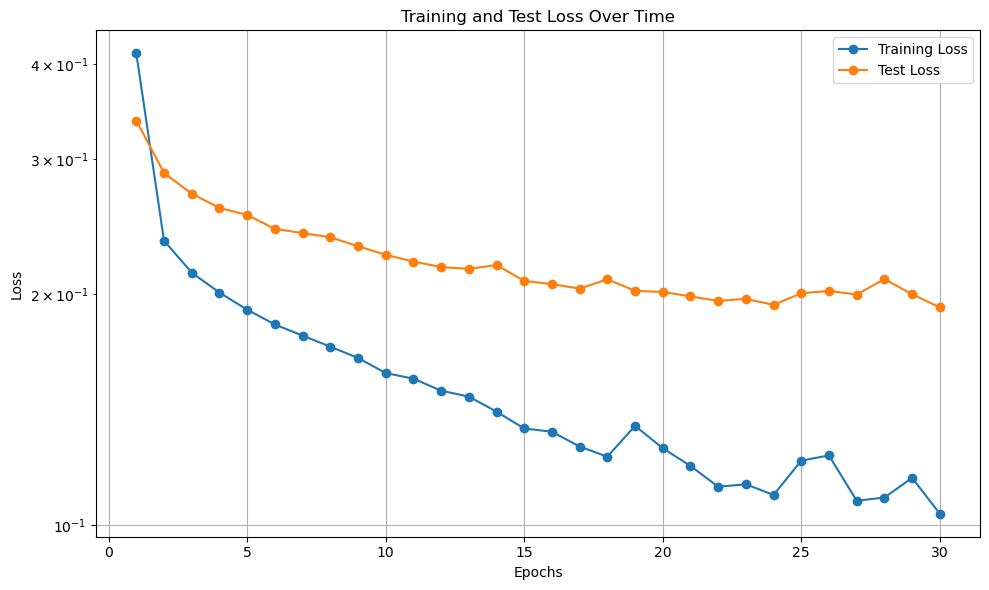

Optimal threshold: 0.246238, F1 score: 0.9220
Threshold used: 0.24623849660158179

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    119460
     Anomaly       0.94      0.91      0.92     12215

    accuracy                           0.99    131675
   macro avg       0.96      0.95      0.96    131675
weighted avg       0.99      0.99      0.99    131675

Accuracy: 0.9857528004556674
F1 Score: 0.9220477021524142
Precision: 0.9362079149438866
Recall: 0.9083094555873925
ROC-AUC: 0.9879999673109426


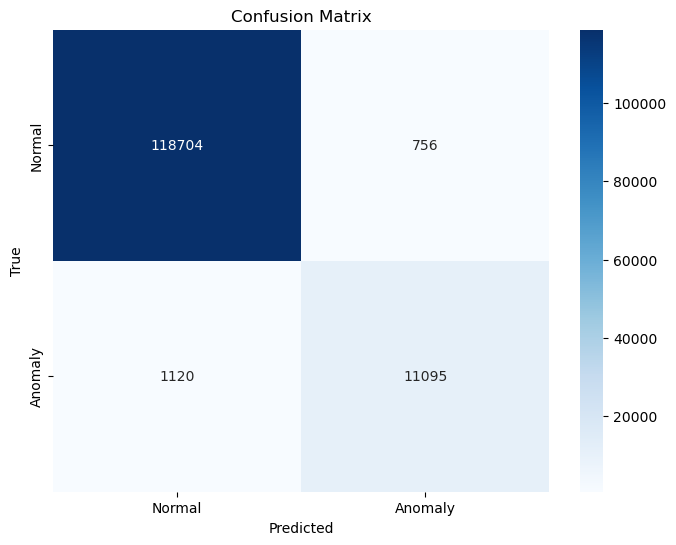


----- MISCLASSIFICATION ANALYSIS -----
Number of false negatives (missed attacks): 1120
Number of false positives (false alarms): 756

🚨 MISSED ATTACKS (False Negatives):

Attack type distribution in missed attacks:
Attack_Type
DoS_DoS-UDP_Flood               282
VulnerabilityScan               203
DDoS_DDoS-HTTP Flood            183
DDoS_DDoS ACK Fragmentation     147
DDoS_DDoS-ICMP_Fragmentation    132
DDoS_DDoS ICMP Flood             80
DoS_DoS SYN Flood                47
DoS_DoS-HTTP_Flood               46
Name: count, dtype: int64

Percentage of each attack type that was missed:
DoS_DoS-UDP_Flood: 3.61% missed (282/7812)
VulnerabilityScan: 30.71% missed (203/661)
DDoS_DDoS-HTTP Flood: 24.14% missed (183/758)
DDoS_DDoS ACK Fragmentation: 4.00% missed (147/3675)
DDoS_DDoS-ICMP_Fragmentation: 27.44% missed (132/481)
DDoS_DDoS ICMP Flood: 26.40% missed (80/303)
DoS_DoS SYN Flood: 0.19% missed (47/24434)
DoS_DoS-HTTP_Flood: 1.97% missed (46/2331)

Feature comparison for missed attacks

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

train_losses = []
test_losses = []

n_epochs = 30
model.train()
for epoch in range(n_epochs):
    
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        inputs = batch[0].to(device)

        if len(inputs.shape) == 2:
            inputs = inputs.unsqueeze(1)  

        outputs, _= model(inputs)  
        loss = criterion(outputs, inputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)



    model.eval()
    with torch.no_grad():
        X_test_tensor_for_loss = X_test_tensor.to(device)

        if len(X_test_tensor_for_loss.shape) == 2:
            X_test_tensor_for_loss = X_test_tensor_for_loss.unsqueeze(1)  

        outputs, _ = model(X_test_tensor_for_loss)
        test_loss = criterion(outputs, X_test_tensor_for_loss).item()
        test_losses.append(test_loss)

    scheduler.step(avg_train_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, n_epochs + 1), test_losses, label='Test Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Time')
plt.legend()
plt.grid(True)
plt.yscale('log')  
plt.tight_layout()
plt.show()


y_test_np = np.array(y_test)

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)

   
    if len(X_test_tensor.shape) == 2:
        X_test_tensor = X_test_tensor.unsqueeze(1) 

    reconstructions, _ = model(X_test_tensor)

    
    if len(X_test_tensor.shape) == 3:
       
        reconstruction_error = torch.mean((X_test_tensor - reconstructions) ** 2, dim=(1, 2)).cpu().numpy()
    else:
       
        reconstruction_error = torch.mean((X_test_tensor - reconstructions) ** 2, dim=1).cpu().numpy()

best_f1 = 0
best_threshold = 0

for percentile in range(0, 100):
    threshold = np.percentile(reconstruction_error, percentile)
    y_pred = (reconstruction_error > threshold).astype(int)
    f1 = f1_score(y_test_np, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Optimal threshold: {best_threshold:.6f}, F1 score: {best_f1:.4f}")

y_pred = (reconstruction_error > best_threshold).astype(int)

print("Threshold used:", best_threshold)
print("\nClassification Report:")
print(classification_report(y_test_np, y_pred, target_names=["Normal", "Anomaly"]))

print("Accuracy:", accuracy_score(y_test_np, y_pred))
print("F1 Score:", f1_score(y_test_np, y_pred))
print("Precision:", precision_score(y_test_np, y_pred))
print("Recall:", recall_score(y_test_np, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_np, reconstruction_error)) 

cm = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

X_indices = np.arange(len(X_scaled))
_, test_indices = train_test_split(
    X_indices, test_size=0.3, random_state=42, stratify=y)


false_negatives = (y_test == 1) & (y_pred == 0)  
false_positives = (y_test == 0) & (y_pred == 1)  


fn_indices = test_indices[false_negatives]
fp_indices = test_indices[false_positives]

missed_attacks_df = df.iloc[fn_indices]
missed_attacks_df.to_csv("missed_attacks_export.csv", index=False)


print("\n----- MISCLASSIFICATION ANALYSIS -----")
print(f"Number of false negatives (missed attacks): {np.sum(false_negatives)}")
print(f"Number of false positives (false alarms): {np.sum(false_positives)}")


if len(fn_indices) > 0:
    missed_attacks_df = df.iloc[fn_indices]

    print("\n🚨 MISSED ATTACKS (False Negatives):")

    print("\nAttack type distribution in missed attacks:")
    attack_type_counts = missed_attacks_df['Attack_Type'].value_counts()
    print(attack_type_counts)

    print("\nPercentage of each attack type that was missed:")
    for attack_type in attack_type_counts.index:
        total_of_type = df[df['Attack_Type'] == attack_type].shape[0]
        missed_of_type = attack_type_counts[attack_type]
        missed_percent = (missed_of_type / total_of_type) * 100
        print(f"{attack_type}: {missed_percent:.2f}% missed ({missed_of_type}/{total_of_type})")


    print("\nFeature comparison for missed attacks vs. all attacks:")

    numeric_cols = missed_attacks_df.select_dtypes(include=['number', 'bool']).columns

    missed_attacks_means = missed_attacks_df[numeric_cols].mean()
    all_attacks_means = df[df['Anomaly_Label'] == 'Attack'][numeric_cols].mean()


    feature_diff = pd.DataFrame({
        'Missed_Attacks_Mean': missed_attacks_means,
        'All_Attacks_Mean': all_attacks_means,
        'Difference': missed_attacks_means - all_attacks_means,
        'Percent_Diff': (missed_attacks_means - all_attacks_means) / all_attacks_means * 100
    })

    feature_diff['Abs_Diff'] = feature_diff['Difference'].abs()
    print(feature_diff.sort_values('Abs_Diff', ascending=False).head(10))
else:
    print("No missed attacks found (no false negatives).")

In [13]:
missed_attacks_df.describe()

,Timestamp,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Std,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Fwd IAT Total,Fwd IAT Std,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Bytes,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Seg Size Min,Active Min,Idle Mean,Idle Std,Weight,Src IP_freq,Dst IP_freq,Src Port_freq,Dst Port_freq
count,1120,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,1.120000e+03,1.120000e+03,1.120000e+03,1.120000e+03,1.120000e+03,1.120000e+03,1.120000e+03,1120.000000,1120.0,1120.0,1120.0,1.120000e+03,1120.000000,1120.000000,1120.000000,1.120000e+03,1120.000000,1120.000000,1120.000000,1120.000000,1120.0,1120.0,1120.000000,1120.0,1120.0,1120.0,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,1.120000e+03,1.120000e+03,1.120000e+03,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000
mean,2022-09-18 11:10:33.153571328,5.717857,1.563393,558.623214,120.266964,26.984183,16.964286,29.913925,21.582111,9.939338e+04,1.280593e+07,9.832147e+05,1.652669e+06,3.612892e+06,1.299011e+06,3.956576e+05,0.030357,0.0,0.0,0.0,2.377623e+04,32.575558,25.835714,274.352679,7.781967e+04,0.323214,0.503571,0.327679,0.675893,0.0,0.0,0.561607,0.0,0.0,0.0,0.431250,584.980357,190.305357,26.945536,9661.300000,360.158036,19.246429,1.861382e+05,3.942880e+06,3.681015e+05,20.078571,11342.354464,17638.713393,2852.460714,29392.808929
min,2022-08-02 10:50:38,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,0.0,1.183368e-02,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,2022-08-11 13:17:07.750000128,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,0.0,3.092125e-01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,77.000000,336.000000,6.000000,4.000000
50%,2022-10-03 17:31:51,2.000000,1.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.899798e+01,4.124600e+04,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,0.0,3.072276e+00,0.451874,0.000000,73.000000,8.533333e+01,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,708.000000,682.000000,10.000000,3070.000000
75%,2022-10-06 15:42:21.500000,5.000000,1.000000,487.000000,44.000000,0.000000,10.000000,36.000000,0.000000,1.000318e+03,6.352905e+06,1.044715e+05,3.031202e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,0.0,2.022539e+01,12.684480,32.000000,251.000000,7.818500e+03,1.000000,1.000000,1.000000,0.000000,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.000000,130.000000,0.000000,14480.000000,0.000000,32.000000,0.000000e+00,6.041448e+06,0.000000e+00,2.000000,8761.000000,19641.000000,606.000000,63765.000000
max,2022-11-29 16:30:04,704.000000,85.000000,146760.000000,7727.000000,1032.375901,511.000000,1156.250000,1417.580186,8.340000e+07,1.199978e+08,4.885983e

In [ ]:

vuln = missed_attacks_df[ missed_attacks_df['Attack_Type'] == 'VulnerabilityScan' ]

print(vuln.describe())

print(vuln.describe(include='all'))


                           Timestamp  Total Fwd Packet  Total Bwd packets  \
count                            203        203.000000         203.000000   
mean   2022-10-03 23:38:55.975369472          3.911330           2.458128   
min              2022-10-03 11:03:45          1.000000           0.000000   
25%       2022-10-03 18:43:50.500000          1.000000           1.000000   
50%              2022-10-03 23:26:25          2.000000           1.000000   
75%              2022-10-04 04:26:57          4.500000           4.000000   
max              2022-10-04 09:27:47         31.000000          25.000000   
std                              NaN          5.604279           3.862997   

       Total Length of Fwd Packet  Total Length of Bwd Packet  \
count                  203.000000                  203.000000   
mean                   305.443350                  219.866995   
min                      0.000000                    0.000000   
25%                      0.000000             

rules for vulnerability scan:

In [ ]:

def apply_rules(df):
    flagged = []

    for idx, row in df.iterrows():
        
        if (
            row['Total Fwd Packet'] <= 10 and
            row['SYN Flag Count'] >= row['Total Fwd Packet'] and
            row['Total Length of Fwd Packet'] <= 200 and
            row['Total Bwd packets'] <= 1 and
            row['Packet Length Variance'] < 1_000 and
            row['Fwd IAT Std'] < 100_000
        ):
            flagged.append(idx)

        if (
            row.get('RST Flag Count', 0) >= 1 and
            row.get('PSH Flag Count', 0) == 0 and
            row.get('FIN Flag Count', 0) == 0
        ):
            flagged.append(idx)

     
        if row['Total Bwd packets'] == 0:
            flagged.append(idx)

        if row.get('Down/Up Ratio', 1) < 0.2:
            flagged.append(idx)
       
    
    return list(set(flagged))

def evaluate_with_rules(y_pred, df, test_indices, y_test):
    test_df = df.iloc[test_indices].copy()
    test_df['rule_flag'] = 0

 
    benign_df = test_df[y_pred == 0]
    flagged = apply_rules(benign_df)
    test_df.loc[flagged, 'rule_flag'] = 1


    test_df['final_pred'] = ((y_pred == 1) | (test_df['rule_flag'] == 1)).astype(int)


    print(classification_report(y_test, test_df['final_pred'],
                                target_names=["Normal","Attack"]))

 
    for attack in ["VulnerabilityScan",
                   "DDoS_DDoS-ICMP_Fragmentation",
                   "DDoS_DDoS ICMP Flood"]:
        subset = test_df[test_df['Attack_Type']==attack]
        n = len(subset)
        d = subset['final_pred'].sum()
        rate = 100*d/n if n else 0
        print(f"- {attack}: {d}/{n} ({rate:.1f}%)")


evaluate_with_rules(y_pred, df, test_indices, y_test)


              precision    recall  f1-score   support

      Normal       0.99      0.55      0.71    119460
      Attack       0.18      0.97      0.30     12215

    accuracy                           0.59    131675
   macro avg       0.59      0.76      0.51    131675
weighted avg       0.92      0.59      0.67    131675

- VulnerabilityScan: 118/204 (57.8%)
- DDoS_DDoS-ICMP_Fragmentation: 47/139 (33.8%)
- DDoS_DDoS ICMP Flood: 46/93 (49.5%)


üsttekinin iyiyleştirmeye çalışılmış versiyonu: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


def apply_rules(df):
    flagged = []
    for idx, row in df.iterrows():
        
        score = 0
        if row['Total Fwd Packet'] <= 5 and row['SYN Flag Count'] >= 0.8 * row['Total Fwd Packet']:
            score += 1
        if row['Total Length of Fwd Packet'] <= 150:
            score += 1
        if row['Total Bwd packets'] <= 1:
            score += 1
        if row['Packet Length Variance'] < 500:
            score += 1
        if row['Fwd IAT Std'] < 2.0:
            score += 1
        if row.get('Down/Up Ratio', 1) < 0.1:
            score += 1
        if score >= 4:
            flagged.append(idx)

        
        if (
            row.get('RST Flag Count', 0) >= 1 and
            row.get('PSH Flag Count', 0) == 0 and
            row.get('FIN Flag Count', 0) == 0
        ):
            flagged.append(idx)

    return list(set(flagged))


def evaluate_with_rules(y_pred, df, test_indices, y_test):
    test_df = df.iloc[test_indices].copy()
    test_df['rule_flag'] = 0

    benign_df = test_df[y_pred == 0]
    flagged = apply_rules(benign_df)
    test_df.loc[flagged, 'rule_flag'] = 1


    test_df['final_pred'] = ((y_pred == 1) | (test_df['rule_flag'] == 1)).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, test_df['final_pred']).ravel()
    total_normals = tn + fp
    total_attacks = tp + fn

 
    print("\n📊 Combined Detection (Model + Rules):")
    print(classification_report(y_test, test_df['final_pred'],
                                target_names=["Normal","Attack"]))


    print(f"\n🛑 False Positives (Normal→Attack): {fp}/{total_normals} "
          f"({100*fp/total_normals:.2f}%)")

    print(f"🚫 False Negatives (Attack→Normal): {fn}/{total_attacks} "
          f"({100*fn/total_attacks:.2f}%)")

    print("\n🔍 Detection Rates for Specific Attack Types:")
    for attack in ["VulnerabilityScan",
                   "DDoS_DDoS-ICMP_Fragmentation",
                   "DDoS_DDoS ICMP Flood"]:
        subset = test_df[test_df['Attack_Type'] == attack]
        n = len(subset)
        d = subset['final_pred'].sum()
        rate = 100 * d / n if n else 0
        print(f"- {attack}: {d}/{n} ({rate:.1f}%)")


evaluate_with_rules(y_pred, df, test_indices, y_test)



📊 Combined Detection (Model + Rules):
              precision    recall  f1-score   support

      Normal       0.99      0.62      0.76    119460
      Attack       0.21      0.96      0.34     12215

    accuracy                           0.65    131675
   macro avg       0.60      0.79      0.55    131675
weighted avg       0.92      0.65      0.73    131675


🛑 False Positives (Normal→Attack): 45199/119460 (37.84%)
🚫 False Negatives (Attack→Normal): 461/12215 (3.77%)

🔍 Detection Rates for Specific Attack Types:
- VulnerabilityScan: 114/204 (55.9%)
- DDoS_DDoS-ICMP_Fragmentation: 64/139 (46.0%)
- DDoS_DDoS ICMP Flood: 47/93 (50.5%)


ilk denenen hali:

In [ ]:
def apply_rules(df):
    flagged = []

    for idx, row in df.iterrows():

        if row['Total Fwd Packet'] <= 10 and row['SYN Flag Count'] >= row['Total Fwd Packet']:
       
            flagged.append(idx)

        if row.get('Proto_1', 0) == 1:
            if row['Packet Length Max'] <= 100 and row['Packet Length Mean'] <= 50:
                flagged.append(idx)

        if row.get('Proto_1', 0) == 1:
            if (row['Fwd Packets/s'] >= 50 and row['Fwd IAT Min'] <= 1):
                flagged.append(idx)

    return list(set(flagged))


model_preds = y_pred  
test_df = df.iloc[test_indices].copy()
test_df['rule_flag'] = 0

benign_df = test_df[model_preds == 0]
flagged_indices = apply_rules(benign_df)
test_df.loc[flagged_indices, 'rule_flag'] = 1

test_df['final_pred'] = ((model_preds == 1) | (test_df['rule_flag'] == 1)).astype(int)


tn, fp, fn, tp = confusion_matrix(y_test, test_df['final_pred']).ravel()
total_normals = tn + fp
total_attacks = tp + fn

print("\n Combined Detection (Model + Rules):")
print(classification_report(y_test, test_df['final_pred'],
                            target_names=["Normal","Attack"]))


print(f"\n False Positives (Normal→Attack): {fp}/{total_normals} "
        f"({100*fp/total_normals:.2f}%)")

print(f" False Negatives (Attack→Normal): {fn}/{total_attacks} "
        f"({100*fn/total_attacks:.2f}%)")




target_attacks = [
    "VulnerabilityScan",
    "DDoS_DDoS-ICMP_Fragmentation",
    "DDoS_DDoS ICMP Flood"
]

print("\n Detection Rates for Specific Attack Types:")
for attack_type in target_attacks:
    subset = test_df[test_df['Attack_Type'] == attack_type]
    total = len(subset)
    detected = subset['final_pred'].sum()
    rate = 100 * detected / total if total > 0 else 0
    print(f"- {attack_type}: {detected}/{total} detected ({rate:.2f}%)")



📊 Combined Detection (Model + Rules):
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.98    119460
      Attack       0.72      0.92      0.81     12215

    accuracy                           0.96    131675
   macro avg       0.86      0.94      0.89    131675
weighted avg       0.97      0.96      0.96    131675


🛑 False Positives (Normal→Attack): 4378/119460 (3.66%)
🚫 False Negatives (Attack→Normal): 992/12215 (8.12%)

🔍 Detection Rates for Specific Attack Types:
- VulnerabilityScan: 38/204 detected (18.63%)
- DDoS_DDoS-ICMP_Fragmentation: 13/139 detected (9.35%)
- DDoS_DDoS ICMP Flood: 18/93 detected (19.35%)
